<>:168: SyntaxWarning: invalid escape sequence '\p'
<>:168: SyntaxWarning: invalid escape sequence '\p'
C:\Users\zifan zhang\AppData\Local\Temp\ipykernel_21152\1886687843.py:168: SyntaxWarning: invalid escape sequence '\p'
  plt.savefig("D:\python\敏感性分析\第二部分\气泡图1.png", dpi=600, bbox_inches='tight')


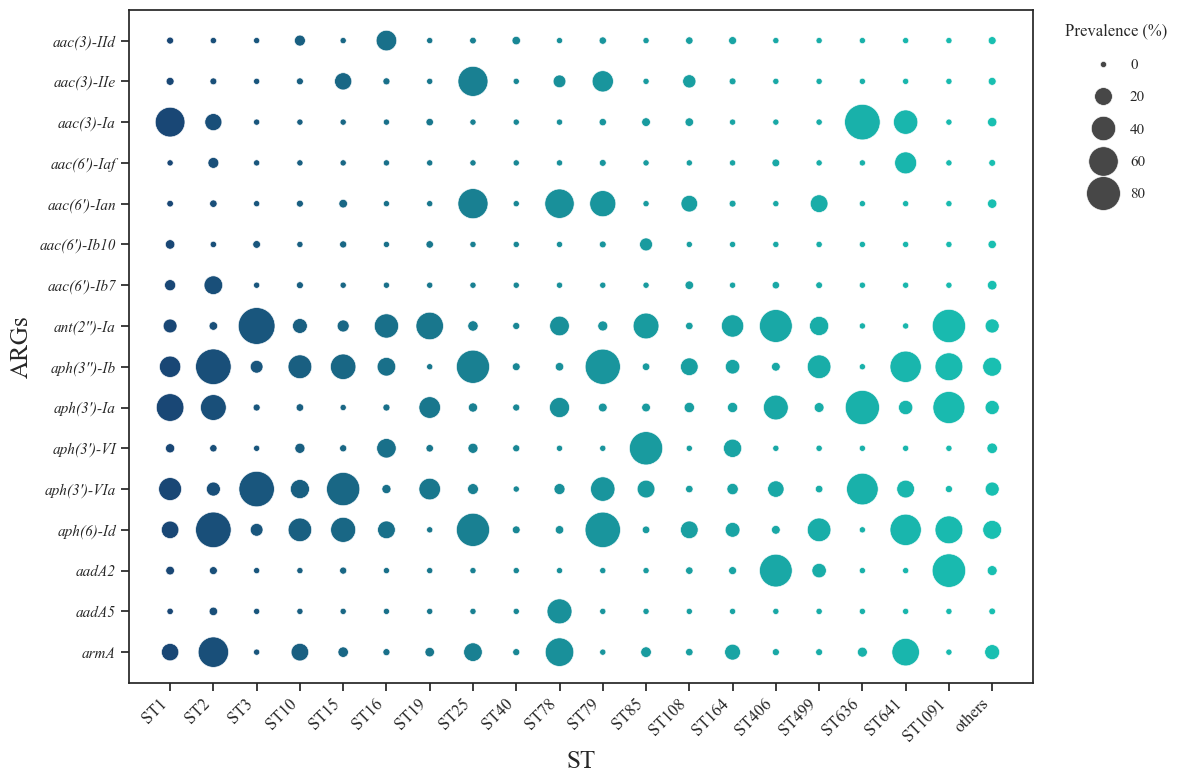

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================= 1. 全局字体及图表样式设置 =================
# 注意：sns.set_theme 必须放在最前面，防止覆盖后面的字体配置
sns.set_theme(style="ticks", font="Times New Roman")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# ================= 2. 数据读取与预处理 =================
target_genes = [
    "AAC(3)-IId",
    "AAC(3)-IIe",
    "AAC(3)-Ia",
    "AAC(6')-Iaf",
    "AAC(6')-Ian",
    "AAC(6')-Ib10",
    "AAC(6')-Ib7",
    "ANT(2'')-Ia",
    "APH(3'')-Ib",
    "APH(3')-Ia",
    "APH(3')-VI",
    "APH(3')-VIa",
    "APH(6)-Id",
    "aadA2",
    "aadA5",
    "armA"
]

try:
    df_test = pd.read_csv(r"D:\A.baumannii\data\ARGs_matched_representatives.csv")
    df_st = pd.read_csv(r"D:\A.baumannii\data\antibiotic_classes_matched_metadata.csv")
except FileNotFoundError:
    print("错误：请确保 ARGs_matched_representatives.csv 和 antibiotic_classes_matched_metadata.csv 路径正确。")
    exit()

available_genes = [gene for gene in target_genes if gene in df_test.columns]
df_test_filtered = df_test[['Genome_ID'] + available_genes]
df_st_filtered = df_st[['Genome_ID', 'st']]

df_merged = pd.merge(df_st_filtered, df_test_filtered, on="Genome_ID", how="inner")

df_long = pd.melt(
    df_merged, 
    id_vars=['Genome_ID', 'st'], 
    value_vars=available_genes,
    var_name='Gene', 
    value_name='Presence'
)

df_long['Presence'] = pd.to_numeric(df_long['Presence'], errors='coerce').fillna(0)
df_long['Presence'] = df_long['Presence'].apply(lambda x: 1 if x > 0 else 0)

# ================= 3. 计算携带率 (Percentage) =================
st_totals = df_long.groupby('st')['Genome_ID'].nunique().reset_index(name='Total_ST_Count')
gene_counts = df_long.groupby(['st', 'Gene'])['Presence'].sum().reset_index(name='Gene_Count')

df_summary = pd.merge(gene_counts, st_totals, on='st')
df_summary['Percentage'] = (df_summary['Gene_Count'] / df_summary['Total_ST_Count']) * 100

# ================= 3.5 核心新增：处理 Y 轴基因名称 =================
# 定义函数：将 APH, AAC, ANT 这种前缀改为小写，后面的保持原样
def format_gene_name(name):
    if name.startswith(("APH", "AAC", "ANT")):
        return name[:3].lower() + name[3:]  # 将前三个字母变成小写
    return name

# 应用函数修改 Gene 列的名字
df_summary['Gene'] = df_summary['Gene'].apply(format_gene_name)

# 附加优化：让图中的 Y 轴严格按照 target_genes 里你定义的顺序来排序
formatted_available_genes = [format_gene_name(g) for g in available_genes]
df_summary['Gene'] = pd.Categorical(df_summary['Gene'], categories=formatted_available_genes, ordered=True)

# ================= 4. 处理标签并智能排序 =================
# 自定义函数：处理 others 不加 ST，其余加 ST
def format_st_name(val):
    s = str(val).strip()
    if s.lower() == 'others':
        return s  # 保持 others 不变
    elif s.startswith('ST'):
        return s
    else:
        return f"ST{s}"

df_summary['st'] = df_summary['st'].apply(format_st_name)

# 智能排序函数：确保ST按数字大小排，且 others 永远在最后
def st_sort_key(x):
    if x.lower() == 'others':
        return (1, 0) # 优先级1，排在最后
    else:
        # 尝试提取 ST 后面的数字进行数值排序
        num_part = x.replace('ST', '')
        if num_part.isdigit():
            return (0, int(num_part)) # 优先级0，按数字大小排
        return (0, float('inf'))

# 获取去重后的标签并排序
unique_sts = sorted(df_summary['st'].unique().tolist(), key=st_sort_key)

# 将 DataFrame 中的 st 列转换为按顺序排列的 Categorical 类型，防止画图时顺序乱掉
df_summary['st'] = pd.Categorical(df_summary['st'], categories=unique_sts, ordered=True)

# ================= 5. 设置蓝绿色渐变色板 =================
# 使用 blend_palette 自定义蓝绿色（蓝 -> 深青 -> 亮蓝绿），避免出现过浅的颜色
custom_palette = sns.blend_palette(["#003366", "#008891", "#00b8a9"], n_colors=len(unique_sts))

# ================= 6. 绘制气泡图 =================
plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=df_summary,
    x="st",
    y="Gene",
    size="Percentage",        
    hue="st",                 
    palette=custom_palette,   
    sizes=(20, 700),          
    alpha=0.9,                
    edgecolor="white",        
    linewidth=0.5
)

# 强制去除网格线
ax.grid(False)

# ================= 7. 图表美化与字体设置 =================
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontstyle='italic', fontsize=11) # 基因名斜体

# 【修改处】：在这里强制加上 fontweight='normal'，去掉默认的加粗
plt.xlabel("ST", fontsize=18, fontweight='normal')
plt.ylabel("ARGs", fontsize=18, fontweight='normal')

# ================= 8. 处理图例 =================
handles, labels = ax.get_legend_handles_labels()

size_handles, size_labels = [], []
capture = False
for h, l in zip(handles, labels):
    if l == "Percentage":
        capture = True
        continue
    if capture:
        size_handles.append(h)
        size_labels.append(l)

# 绘制清理后的图例（只含大小）
plt.legend(
    size_handles, 
    size_labels, 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    title="Prevalence (%)",
    # 【修改处】：将 weight 从 'bold' 改为 'normal'
    title_fontproperties={'family': 'Times New Roman', 'weight': 'normal', 'size': 12},
    # 【修改处】：确保图例内部文字也不加粗
    prop={'family': 'Times New Roman', 'weight': 'normal', 'size': 11}, 
    frameon=False, 
    labelspacing=1.2 
)

plt.tight_layout()

# 保存高质量图片 (可选)
plt.savefig("气泡图1.png", dpi=600, bbox_inches='tight')

# 显示图像
plt.show()


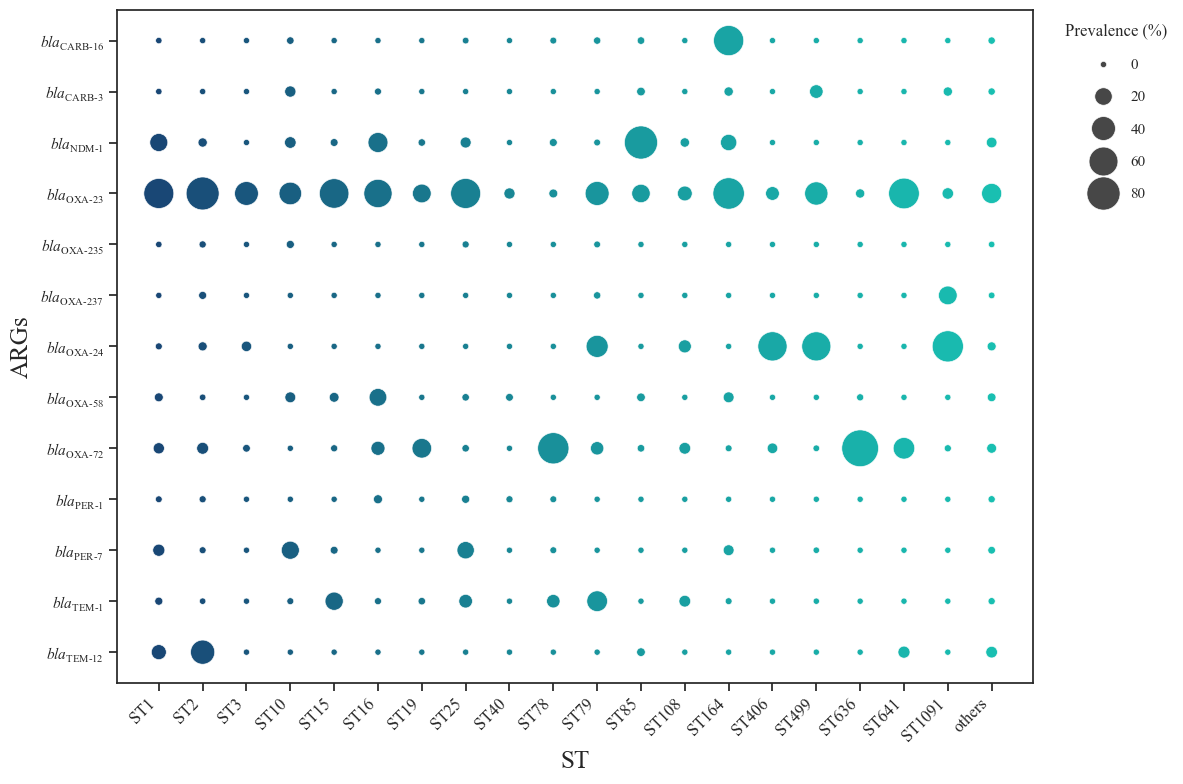

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================= 1. 全局字体及图表样式设置 =================
# 注意：sns.set_theme 必须放在最前面，防止它覆盖掉后面的自定义字体设置
sns.set_theme(style="ticks", font="Times New Roman")

# 强制接管全局及数学公式（Y轴斜体和下标）字体为不加粗的新罗马
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'

# ================= 2. 数据读取与预处理 =================
# 替换为最新的 β-内酰胺酶耐药基因列表
target_genes = [
    "CARB-16",
    "CARB-3",
    "NDM-1",
    "OXA-23",
    "OXA-235",
    "OXA-237",
    "OXA-24",
    "OXA-58",
    "OXA-72",
    "PER-1",
    "PER-7",
    "TEM-1",
    "TEM-12"
]

try:
    df_test = pd.read_csv(r"D:\A.baumannii\data\ARGs_matched_representatives.csv")
    df_st = pd.read_csv(r"D:\A.baumannii\data\antibiotic_classes_matched_metadata.csv")
except FileNotFoundError:
    print("错误：请确保 ARGs_matched_representatives.csv 和 antibiotic_classes_matched_metadata.csv 在当前目录下。")
    exit()

# 筛选存在的基因，防止列名拼写错误报错
available_genes = [gene for gene in target_genes if gene in df_test.columns]
df_test_filtered = df_test[['Genome_ID'] + available_genes]
df_st_filtered = df_st[['Genome_ID', 'st']]

df_merged = pd.merge(df_st_filtered, df_test_filtered, on="Genome_ID", how="inner")

# 宽表变长表
df_long = pd.melt(
    df_merged, 
    id_vars=['Genome_ID', 'st'], 
    value_vars=available_genes,
    var_name='Gene', 
    value_name='Presence'
)

# 转换为 0/1 (大于0即为携带)
df_long['Presence'] = pd.to_numeric(df_long['Presence'], errors='coerce').fillna(0)
df_long['Presence'] = df_long['Presence'].apply(lambda x: 1 if x > 0 else 0)

# ================= 3. 计算携带率 (Percentage) =================
st_totals = df_long.groupby('st')['Genome_ID'].nunique().reset_index(name='Total_ST_Count')
gene_counts = df_long.groupby(['st', 'Gene'])['Presence'].sum().reset_index(name='Gene_Count')

df_summary = pd.merge(gene_counts, st_totals, on='st')
df_summary['Percentage'] = (df_summary['Gene_Count'] / df_summary['Total_ST_Count']) * 100

# ================= 4. 处理标签并智能排序 =================
# X轴：处理 others 不加 ST，其余加 ST
def format_st_name(val):
    s = str(val).strip()
    if s.lower() == 'others':
        return s
    elif s.startswith('ST'):
        return s
    else:
        return f"ST{s}"

df_summary['st'] = df_summary['st'].apply(format_st_name)

# X轴：ST按数字大小排，others 永远在最后
def st_sort_key(x):
    if x.lower() == 'others':
        return (1, 0)
    else:
        num_part = x.replace('ST', '')
        if num_part.isdigit():
            return (0, int(num_part))
        return (0, float('inf'))

unique_sts = sorted(df_summary['st'].unique().tolist(), key=st_sort_key)
df_summary['st'] = pd.Categorical(df_summary['st'], categories=unique_sts, ordered=True)

# ================= 新增核心修改：处理 Y轴 bla 格式 (不加粗) =================
def format_bla_gene(gene):
    # 将 '-' 替换，保证横杠前后的字符都应用 \mathrm (普通正体)，并用 \text{-} 防止横杠过长
    gene_math = str(gene).replace('-', r'}\text{-}\mathrm{')
    # \mathit{} : 普通斜体 bla
    # \mathrm{} : 普通正体 下标
    # 组合效果: $\mathit{bla}_{\mathrm{OXA}\text{-}\mathrm{23}}$
    return rf'$\mathit{{bla}}_{{\mathrm{{{gene_math}}}}}$'

# Y轴：直接应用公式渲染字符串
df_summary['Gene_Display'] = df_summary['Gene'].apply(format_bla_gene)

# 锁定Y轴基因的显示顺序（与您提供的列表顺序一致）
display_genes_order = [format_bla_gene(gene) for gene in available_genes]
df_summary['Gene_Display'] = pd.Categorical(df_summary['Gene_Display'], categories=display_genes_order, ordered=True)
# ==================================================================

# ================= 5. 设置蓝绿色渐变色板 =================
# 深蓝 -> 蓝绿 -> 亮湖蓝，保证最右侧依然清晰可见
custom_palette = sns.blend_palette(["#003366", "#008891", "#00b8a9"], n_colors=len(unique_sts))

# ================= 6. 绘制气泡图 =================
plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=df_summary,
    x="st",
    y="Gene_Display",         # 使用带格式的新列作为Y轴
    size="Percentage",        
    hue="st",                 
    palette=custom_palette,   
    sizes=(20, 700),          
    alpha=0.9,                
    edgecolor="white",        
    linewidth=0.5
)

# 强制去除网格线
ax.grid(False)

# ================= 7. 图表美化与字体设置 =================
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=11) 

plt.xlabel("ST", fontsize=18)
plt.ylabel("ARGs", fontsize=18)

# ================= 8. 处理图例 =================
handles, labels = ax.get_legend_handles_labels()

size_handles, size_labels = [], []
capture = False
for h, l in zip(handles, labels):
    if l == "Percentage":
        capture = True
        continue
    if capture:
        size_handles.append(h)
        size_labels.append(l)

# 绘制只包含携带率大小的图例
plt.legend(
    size_handles, 
    size_labels, 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    title="Prevalence (%)",
    # 【修改处】：取消了 title_fontproperties 的 'weight': 'bold'，改为 'normal'
    title_fontproperties={'family': 'Times New Roman', 'weight': 'normal', 'size': 12},
    # 【新增】：强制保障图例内部文本也使用 Times New Roman
    prop={'family': 'Times New Roman', 'size': 11}, 
    frameon=False, 
    labelspacing=1.2 
)

plt.tight_layout()

# 保存图像(可选)
plt.savefig("气泡图2.png",  dpi=600, bbox_inches='tight')

# 显示图像
plt.show()


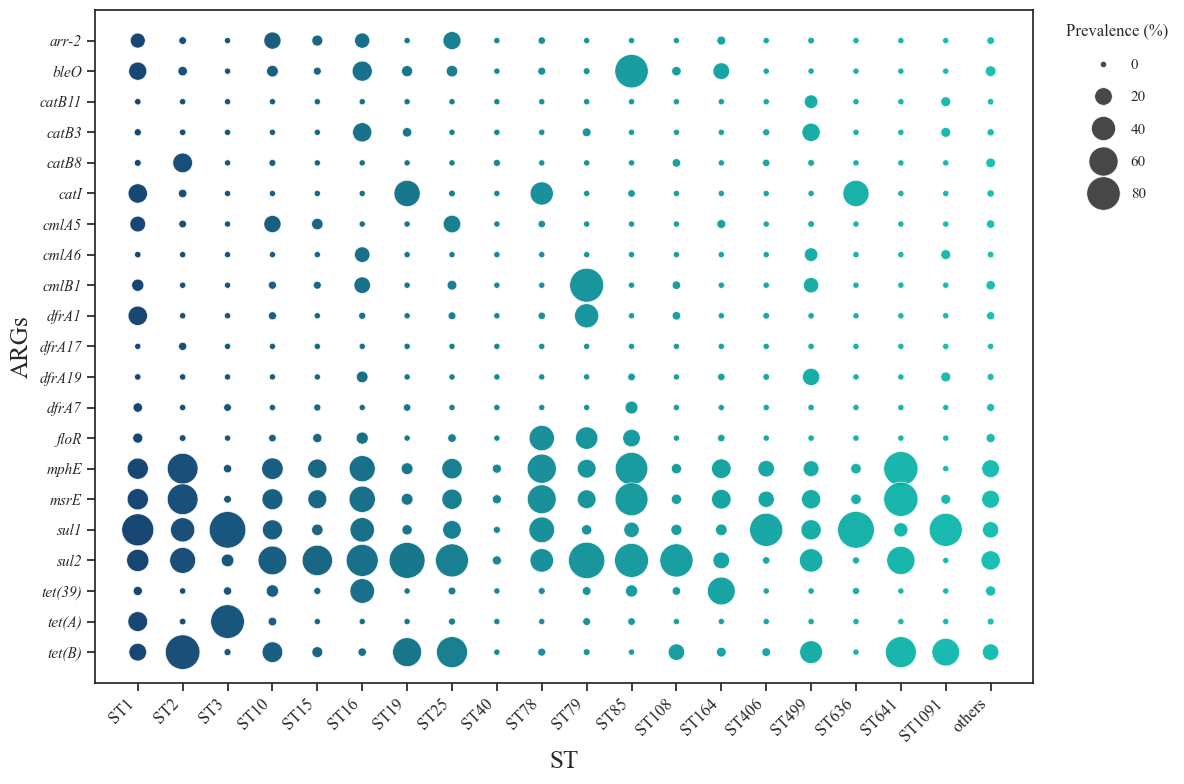

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================= 1. 全局字体及图表样式设置 =================
plt.rcParams['font.family'] = 'Times New Roman'
sns.set_theme(style="ticks", font="Times New Roman")

# ================= 2. 数据读取与预处理 =================
target_genes = [
    "bleO",
    "dfrA1", "dfrA17", "dfrA19", "dfrA7",
    "mphE", "msrE",
    "catB11", "catB3", "catB8", "catI",
    "cmlA5", "cmlA6", "cmlB1", "floR",
    "arr-2",
    "sul1", "sul2",
    "tet(39)", "tet(A)", "tet(B)"
]

try:
    df_test = pd.read_csv(r"D:\A.baumannii\data\ARGs_matched_representatives.csv")
    df_st = pd.read_csv(r"D:\A.baumannii\data\antibiotic_classes_matched_metadata.csv")
except FileNotFoundError:
    print("错误：请确保 ARGs_matched_representatives.txt 和 antibiotic_classes_matched_metadata.txt 在当前目录下。")
    exit()

available_genes = [gene for gene in target_genes if gene in df_test.columns]
df_test_filtered = df_test[['Genome_ID'] + available_genes]
df_st_filtered = df_st[['Genome_ID', 'st']]

df_merged = pd.merge(df_st_filtered, df_test_filtered, on="Genome_ID", how="inner")

df_long = pd.melt(
    df_merged, 
    id_vars=['Genome_ID', 'st'], 
    value_vars=available_genes,
    var_name='Gene', 
    value_name='Presence'
)

df_long['Presence'] = pd.to_numeric(df_long['Presence'], errors='coerce').fillna(0)
df_long['Presence'] = df_long['Presence'].apply(lambda x: 1 if x > 0 else 0)

# ================= 3. 计算携带率 (Percentage) =================
st_totals = df_long.groupby('st')['Genome_ID'].nunique().reset_index(name='Total_ST_Count')
gene_counts = df_long.groupby(['st', 'Gene'])['Presence'].sum().reset_index(name='Gene_Count')

df_summary = pd.merge(gene_counts, st_totals, on='st')
df_summary['Percentage'] = (df_summary['Gene_Count'] / df_summary['Total_ST_Count']) * 100

# ================= 4. 处理标签并智能排序 =================
# 自定义函数：处理 others 不加 ST，其余加 ST
def format_st_name(val):
    s = str(val).strip()
    if s.lower() == 'others':
        return s  # 保持 others 不变
    elif s.startswith('ST'):
        return s
    else:
        return f"ST{s}"

df_summary['st'] = df_summary['st'].apply(format_st_name)

# 智能排序函数：确保ST按数字大小排，且 others 永远在最后
def st_sort_key(x):
    if x.lower() == 'others':
        return (1, 0) # 优先级1，排在最后
    else:
        # 尝试提取 ST 后面的数字进行数值排序
        num_part = x.replace('ST', '')
        if num_part.isdigit():
            return (0, int(num_part)) # 优先级0，按数字大小排
        return (0, float('inf'))

# 获取去重后的标签并排序
unique_sts = sorted(df_summary['st'].unique().tolist(), key=st_sort_key)

# 将 DataFrame 中的 st 列转换为按顺序排列的 Categorical 类型，防止画图时顺序乱掉
df_summary['st'] = pd.Categorical(df_summary['st'], categories=unique_sts, ordered=True)

# ================= 5. 设置蓝绿色渐变色板 =================
# 使用 blend_palette 自定义蓝绿色（蓝 -> 深青 -> 亮蓝绿），避免出现过浅的颜色
# "#003366" (深蓝) -> "#008080" (青色) -> "#00b8a9" (亮蓝绿)
custom_palette = sns.blend_palette(["#003366", "#008891", "#00b8a9"], n_colors=len(unique_sts))

# ================= 6. 绘制气泡图 =================
plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=df_summary,
    x="st",
    y="Gene",
    size="Percentage",        
    hue="st",                 
    palette=custom_palette,   # 应用自定义的蓝绿色系色板
    sizes=(20, 700),          
    alpha=0.9,                # 稍微提高一点透明度，让颜色更实
    edgecolor="white",        
    linewidth=0.5
)

# 强制去除网格线
ax.grid(False)

# ================= 7. 图表美化与字体设置 =================
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontstyle='italic', fontsize=11) # 基因名斜体

plt.xlabel("ST", fontsize=18)
plt.ylabel("ARGs", fontsize=18)

# ================= 8. 处理图例 =================
handles, labels = ax.get_legend_handles_labels()

size_handles, size_labels = [], []
capture = False
for h, l in zip(handles, labels):
    if l == "Percentage":
        capture = True
        continue
    if capture:
        size_handles.append(h)
        size_labels.append(l)

# 绘制清理后的图例（只含大小）
plt.legend(
    size_handles, 
    size_labels, 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    title="Prevalence (%)",
    title_fontproperties={'family': 'Times New Roman', 'weight': 'normal', 'size': 12},
    frameon=False, 
    labelspacing=1.2 
)

plt.tight_layout()

# 保存高质量图片 (可选)
plt.savefig("气泡图3.png",dpi=600, bbox_inches='tight')

# 显示图像
plt.show()